****Marketing A/B testing****
by Siti Nurul Azizah

About Dataset
Marketing A/B testing dataset
Marketing companies want to run successful campaigns, but the market is complex and several options can work. So normally they tun A/B tests, that is a randomized experimentation process wherein two or more versions of a variable (web page, page element, banner, etc.) are shown to different segments of people at the same time to determine which version leaves the maximum impact and drive business metrics.

The companies are interested in answering two questions:

- Would the campaign be successful?
- If the campaign was successful, how much of that success could be attributed to the ads?
With the second question in mind, we normally do an A/B test. The majority of the people will be exposed to ads (the experimental group). And a small portion of people (the control group) would instead see a Public Service Announcement (PSA) (or nothing) in the exact size and place the ad would normally be.

The idea of the dataset is to analyze the groups, find if the ads were successful, how much the company can make from the ads, and if the difference between the groups is statistically significant.

Data dictionary:

Index: Row index
- user id: User ID (unique)
- test group: If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement
- converted: If a person bought the product then True, else is False
- total ads: Amount of ads seen by person
- most ads day: Day that the person saw the biggest amount of ads
-most ads hour: Hour of day that the person saw the biggest amount of ads



**Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

**Load Dataset**

In [3]:
df = pd.read_csv("marketing_AB.csv")
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279668,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [17]:
psa_data = df[df['test_group'] == 'psa'][['test_group', 'total_ads']]
psa_data.head()

,test_group,total_ads
18,psa,248
38,psa,27
68,psa,13
140,psa,32
157,psa,105


**Data Cleaning**

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df.isnull().sum()

unnamed:_0       0
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [7]:
df.duplicated().sum()

0

**Exploratory Data Analysis**

In [8]:
df['test_group'].value_counts()

test_group
ad     564577
psa     23524
Name: count, dtype: int64

In [9]:
conversion_rate = df.groupby('test_group')['converted'].mean()
print(conversion_rate)

test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


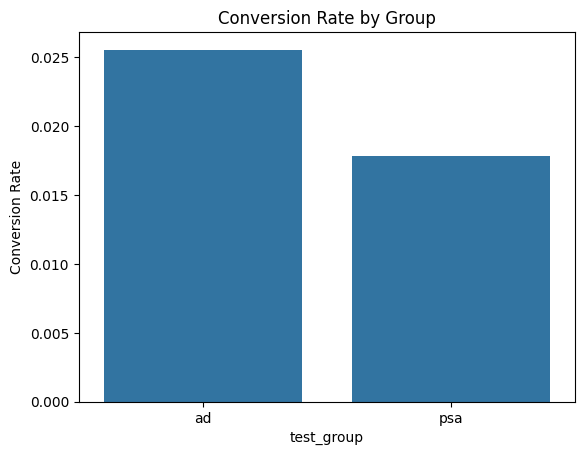

In [10]:
sns.barplot(x=conversion_rate.index, y=conversion_rate.values)
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()

In [22]:
df.groupby('converted')['total_ads'].mean()

converted
False    23.291495
True     83.887759
Name: total_ads, dtype: float64

<Axes: xlabel='converted', ylabel='total_ads'>

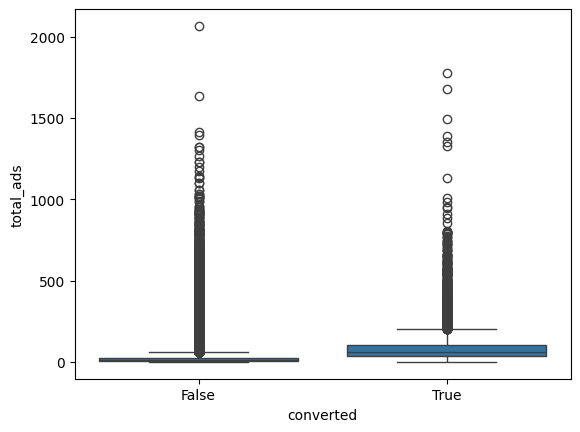

In [23]:
sns.boxplot(x='converted', y='total_ads', data=df)

In [24]:
df.groupby(['test_group','most_ads_day'])['converted'].mean()

test_group  most_ads_day
ad          Friday          0.022465
            Monday          0.033241
            Saturday        0.021307
            Sunday          0.024620
            Thursday        0.021637
            Tuesday         0.030440
            Wednesday       0.025356
psa         Friday          0.016303
            Monday          0.022559
            Saturday        0.013996
            Sunday          0.020595
            Thursday        0.020230
            Tuesday         0.014448
            Wednesday       0.015759
Name: converted, dtype: float64

5. Hypothesis Testing (Z-Test)

Hipotesis:

H0: Conversion rate ad = psa
H1: Conversion rate ad ≠ psa

In [11]:
conversion_counts = df.groupby('test_group')['converted'].sum()
n_obs = df.groupby('test_group')['converted'].count()

z_stat, p_value = proportions_ztest(
    count=conversion_counts,
    nobs=n_obs
)

print("Z-stat:", z_stat)
print("P-value:", p_value)

Z-stat: 7.3700781265454145
P-value: 1.7052807161559727e-13


In [15]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0 → terdapat perbedaan signifikan")
else:
    print("Fail to reject H0 → tidak signifikan")

Reject H0 → terdapat perbedaan signifikan


In [12]:
contingency = pd.crosstab(df['test_group'], df['converted'])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi2:", chi2)
print("P-value:", p)

Chi2: 54.005823883685245
P-value: 1.9989623063390075e-13


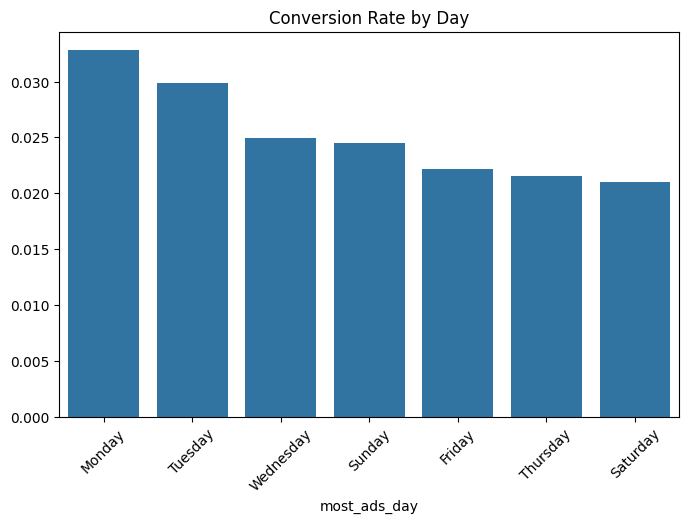

In [13]:
day_conv = df.groupby('most_ads_day')['converted'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=day_conv.index, y=day_conv.values)
plt.title("Conversion Rate by Day")
plt.xticks(rotation=45)
plt.show()

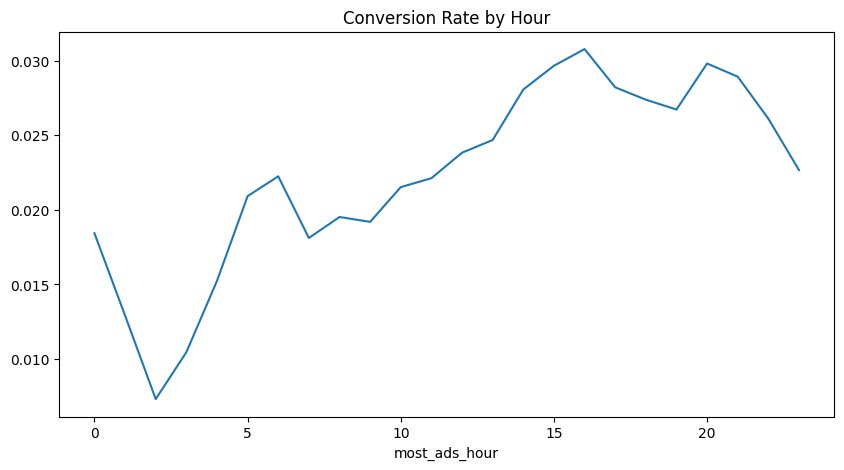

In [14]:
hour_conv = df.groupby('most_ads_hour')['converted'].mean()

plt.figure(figsize=(10,5))
sns.lineplot(x=hour_conv.index, y=hour_conv.values)
plt.title("Conversion Rate by Hour")
plt.show()